In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('applicants_cleaned.csv', parse_dates=['Application Date'], dtype={'Phone': str})

# Week 2 - Exploratory Data Analysis: NextGenLearners Applicant Insights

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Applicant Name    81 non-null     object        
 1   Email             81 non-null     object        
 2   Phone             81 non-null     object        
 3   Domain Applied    81 non-null     object        
 4   University        81 non-null     object        
 5   Application Date  77 non-null     datetime64[ns]
 6   Status            81 non-null     object        
dtypes: datetime64[ns](1), object(6)
memory usage: 4.6+ KB


In [6]:
df.head()

,Applicant Name,Email,Phone,Domain Applied,University,Application Date,Status
0,Steven Miller,jessebenson@example.net,03171484348,Digital Marketing,FAST NUCES,NaT,Rejected
1,Megan Joyce,brownjessica@example.org,03127194416,App Development,FAST NUCES,2025-10-15,Under Review
2,Danielle Odonnell,davisrodney@example.com,03348030010,Digital Marketing,Karachi University,2025-01-08,Under Review
3,Thomas Bradley,jason76@example.net,03106438436,Web Development,LUMS,2025-12-30,Under Review
4,Kimberly Smith,housemelinda@example.org,03202813543,Web Development,Karachi University,2025-11-12,Selected


In [7]:
df['Phone'].head()

,Phone
0,03171484348
1,03127194416
2,03348030010
3,03106438436
4,03202813543


## Question 1: Which domain received the most applications?

In [8]:
domain_counts = df['Domain Applied'].value_counts()
print(domain_counts)

Domain Applied
App Development      24
Digital Marketing    16
Graphic Design       15
Web Development      13
Data Science         13
Name: count, dtype: int64


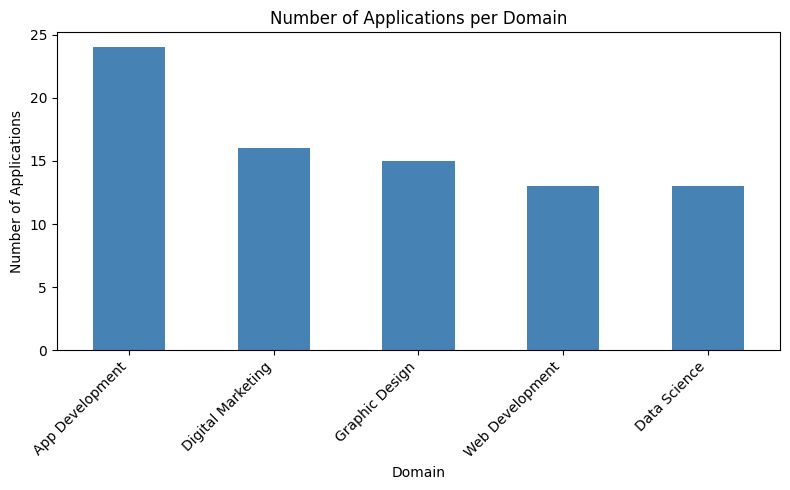

In [9]:
plt.figure(figsize=(8,5))
domain_counts.plot(kind='bar', color='steelblue')
plt.title('Number of Applications per Domain')
plt.xlabel('Domain')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Takeaway:** App Development received the highest number of applications (24),
followed by Digital Marketing (16) and Graphic Design (15). Web Development and
Data Science received the fewest applications, tied at 13 each — nearly half
of App Development's count.

## Question 2: How did applications trend over time?

In [10]:
df['Application Month'] = df['Application Date'].dt.to_period('M')
monthly_trend = df.groupby('Application Month').size()
print(monthly_trend)

Application Month
2025-01     3
2025-04     1
2025-07     2
2025-08     9
2025-09     5
2025-10    10
2025-11     5
2025-12     6
2026-01     6
2026-02     6
2026-03     4
2026-04     4
2026-05     5
2026-06     6
2026-07     4
2026-10     1
Freq: M, dtype: int64


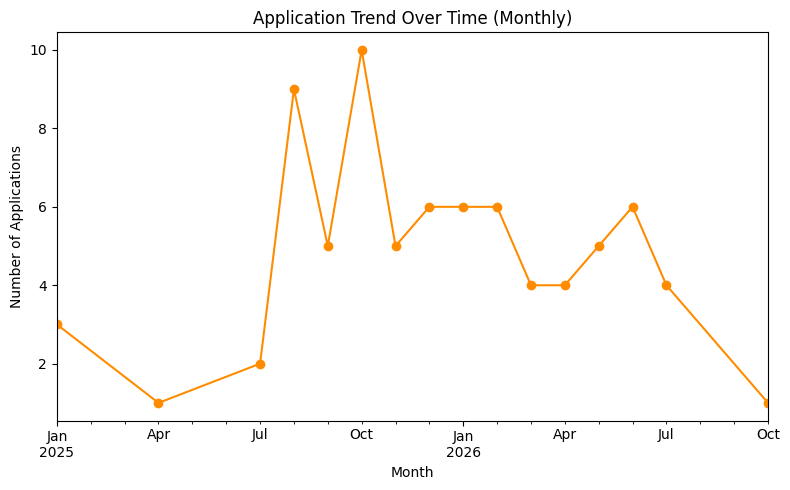

In [11]:
plt.figure(figsize=(8,5))
monthly_trend.plot(kind='line', marker='o', color='darkorange')
plt.title('Application Trend Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.tight_layout()
plt.show()

**Takeaway:** Applications peaked in October 2025 (10 applications), with
August 2025 (9) also showing a strong month. Volume dropped significantly in
early months (January and April 2025) and has remained relatively steady,
averaging around 4-6 applications per month since late 2025, with a sharp
drop-off by October 2026.

## Question 3: What's the acceptance rate — overall and per domain?

In [12]:
status_counts = df['Status'].value_counts()
print(status_counts)

Status
Selected        32
Under Review    27
Rejected        22
Name: count, dtype: int64


In [13]:
status_by_domain = pd.pivot_table(
    df,
    index='Domain Applied',
    columns='Status',
    values='Applicant Name',
    aggfunc='count',
    fill_value=0
)
print(status_by_domain)

Status             Rejected  Selected  Under Review
Domain Applied                                     
App Development           8        11             5
Data Science              4         6             3
Digital Marketing         4         4             8
Graphic Design            3         8             4
Web Development           3         3             7


In [14]:
status_by_domain_pct = status_by_domain.div(status_by_domain.sum(axis=1), axis=0) * 100
print(status_by_domain_pct.round(1))

Status             Rejected  Selected  Under Review
Domain Applied                                     
App Development        33.3      45.8          20.8
Data Science           30.8      46.2          23.1
Digital Marketing      25.0      25.0          50.0
Graphic Design         20.0      53.3          26.7
Web Development        23.1      23.1          53.8


**Takeaway:** Overall, 32 applicants were Selected (39.5%), 27 are Under Review,
and 22 were Rejected. Looking per domain, Graphic Design has the highest
acceptance rate (53.3%), followed closely by Data Science (46.2%) and App
Development (45.8%). Web Development and Digital Marketing have notably lower
selection rates (23.1% and 25.0%) but a much larger share Under Review
(53.8% and 50.0%), suggesting many of their applications are still pending
a decision.

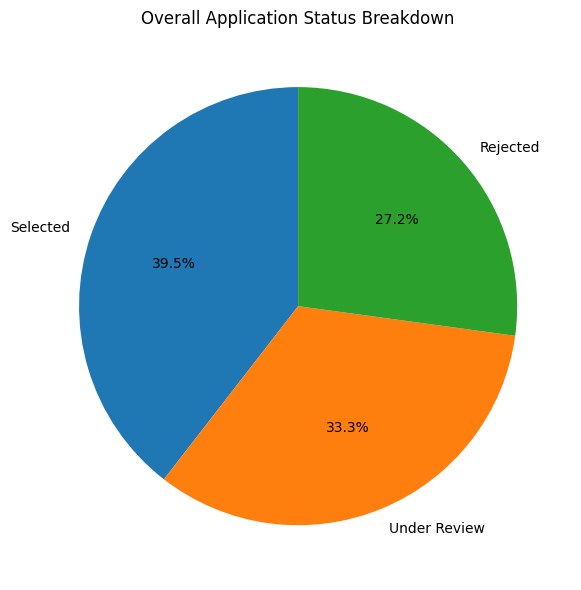

In [15]:
plt.figure(figsize=(6,6))
status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Overall Application Status Breakdown')
plt.ylabel('')
plt.tight_layout()
plt.show()

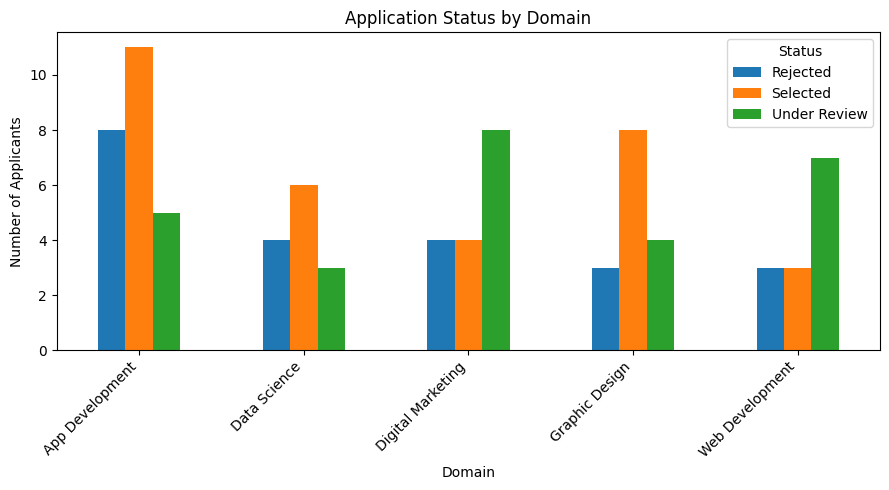

In [16]:
status_by_domain.plot(kind='bar', figsize=(9,5))
plt.title('Application Status by Domain')
plt.xlabel('Domain')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

## Question 4: Which universities sent the most applicants?

In [17]:
top_universities = df['University'].value_counts().head(10)
print(top_universities)

University
Not Specified            11
Sukkur IBA               11
SIBA                     10
NED University            9
Sukkur IBA University     8
FAST NUCES                8
UET Lahore                7
LUMS                      7
Karachi University        5
Comsats                   5
Name: count, dtype: int64


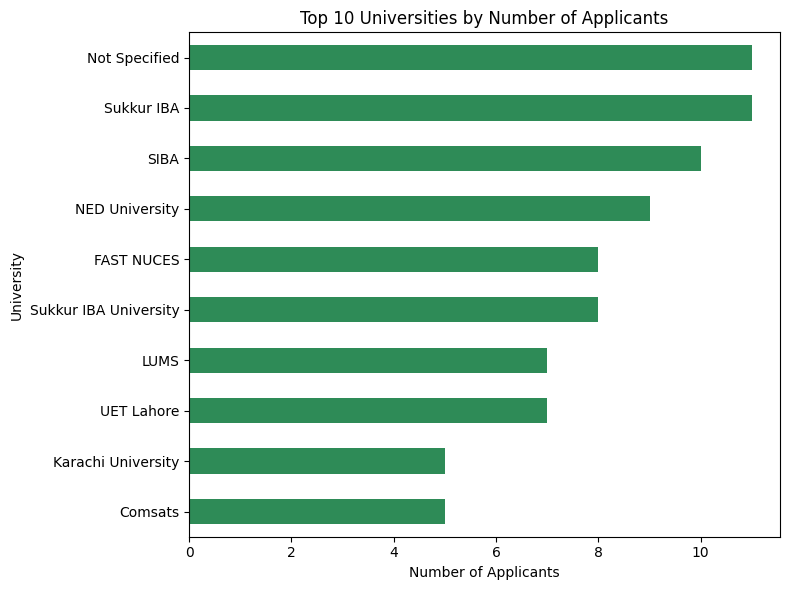

In [18]:
plt.figure(figsize=(8,6))
top_universities.sort_values().plot(kind='barh', color='seagreen')
plt.title('Top 10 Universities by Number of Applicants')
plt.xlabel('Number of Applicants')
plt.ylabel('University')
plt.tight_layout()
plt.show()

In [19]:
university_mapping = {
    'SIBA': 'Sukkur IBA University',
    'Sukkur IBA': 'Sukkur IBA University',
    'Sukkur IBA University': 'Sukkur IBA University',
}
df['University'] = df['University'].replace(university_mapping)

In [20]:
top_universities = df['University'].value_counts().head(10)
print(top_universities)

University
Sukkur IBA University    29
Not Specified            11
NED University            9
FAST NUCES                8
UET Lahore                7
LUMS                      7
Karachi University        5
Comsats                   5
Name: count, dtype: int64


In [21]:
top_universities = df['University'].value_counts().head(10)
print(top_universities)

University
Sukkur IBA University    29
Not Specified            11
NED University            9
FAST NUCES                8
UET Lahore                7
LUMS                      7
Karachi University        5
Comsats                   5
Name: count, dtype: int64


**Takeaway:** After standardizing name variants (SIBA, Sukkur IBA, and Sukkur
IBA University were the same institution written differently), Sukkur IBA
University emerges as the clear top contributor with 29 applicants — more
than 2.5x the next highest (NED University, 9). 11 applications had no
university specified, highlighting a data collection gap worth addressing
in future application forms.

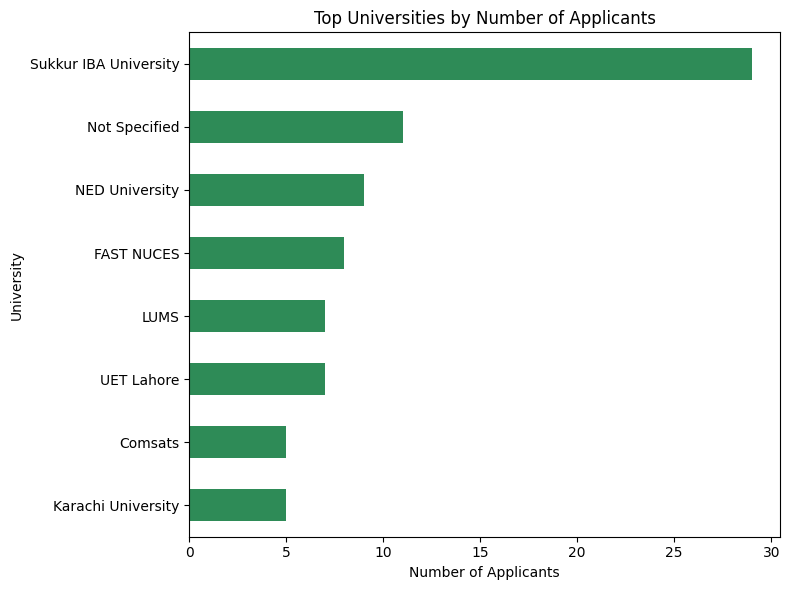

In [23]:
plt.figure(figsize=(8,6))
top_universities.sort_values().plot(kind='barh', color='seagreen')
plt.title('Top Universities by Number of Applicants')
plt.xlabel('Number of Applicants')
plt.ylabel('University')
plt.tight_layout()
plt.show()

## Bonus Question: Which day of the week receives the most applications?

In [24]:
df['Day of Week'] = df['Application Date'].dt.day_name()
day_counts = df['Day of Week'].value_counts()
print(day_counts)

Day of Week
Tuesday      15
Wednesday    13
Saturday     12
Friday       11
Sunday       10
Monday        9
Thursday      7
Name: count, dtype: int64


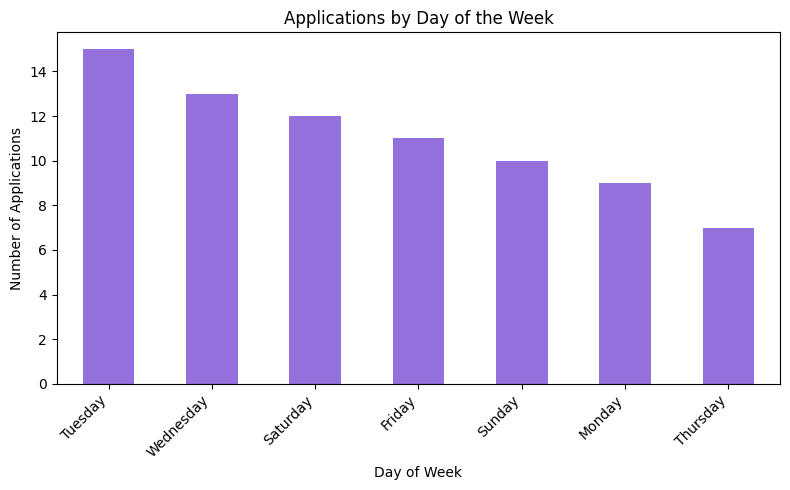

In [25]:
plt.figure(figsize=(8,5))
day_counts.plot(kind='bar', color='mediumpurple')
plt.title('Applications by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Why this question:** I was curious whether applicants tend to apply during
weekdays (work/study hours) or weekends, which could inform when NextGenLearners
should schedule outreach or reminder emails.

**Takeaway:** Tuesday is the most popular day for applications (15), followed
by Wednesday (13). Weekday applications (Mon-Fri: 55) significantly outnumber
weekend applications (Sat-Sun: 22), suggesting most applicants engage during
their regular week rather than on weekends — reminder emails or outreach
pushed on Tuesdays/Wednesdays may see the best response.

## Key Insights

- App Development is the most popular domain by application volume (24),
  nearly double that of Web Development or Data Science (13 each),
  suggesting stronger interest or awareness for this track.

- Applications peaked sharply in October 2025 (10) and August 2025 (9),
  while remaining steady at 4-6 per month through most of 2026 — outreach
  timing around August-October appears most effective.

- While App Development receives the most applications, Graphic Design has
  the highest acceptance rate (53.3%) and Data Science the second highest
  (46.2%), suggesting these tracks may have a stronger average applicant
  pool or less competition per seat.

- Web Development and Digital Marketing have over half their applicants
  still Under Review (53.8% and 50.0%), indicating a review backlog in
  these domains that may need attention.

- After correcting inconsistent university name entries, Sukkur IBA
  University accounts for 29 of 81 applicants (~36%) — by far the largest
  single source — while 11 applications have no university listed,
  pointing to a data collection gap in the form.

- Applications are notably higher on weekdays (55) than weekends (22),
  with Tuesday being the single most active day (15) — a good day to
  schedule reminder outreach.